<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/main/experiments/exp_03_plain_classifier/ResNet50_plain_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet50 + Dense(5) + softmax — Plain image classifier

**Experiment:** `exp_03_plain_classifier` — control ablation for *A Study on Foundational Visual-Language Models for Histopathology Image Analysis*.

**Purpose of this notebook.** This is the no-CLIP-architecture control row for the project. It uses the *same* frozen ResNet50 image features and the *same* stratified 80/10/10 split as the baseline, but the entire CLIP paradigm is removed: there is no text encoder, no projection head, no learnable temperature, no InfoNCE loss. The image branch ends in a Dense(5) classifier trained with sparse cross-entropy. The $\Delta$ against the CLIP baseline isolates what the CLIP architecture contributes once the image encoder and data are held constant.

**Design choices that differ from the baseline.**

- **No text branch.** BERT, the text projection, and the prompts are dropped entirely.
- **Loss.** Sparse cross-entropy on softmax outputs, instead of symmetric InfoNCE.
- **Head.** A single `Dense(NUM_CLASSES)` on top of the global-average-pooled ResNet50 features.
- **Training signal.** Per-sample class labels, not per-batch image-text similarity.

Everything else (frozen ResNet50, image preprocessing, batch size, optimiser, callbacks, eval set) is identical to the baseline so the $\Delta$ is attributable to the architecture and loss change only.

## 0 — Setup

Self-bootstrapping on Google Colab: clones the repo so `src/` is importable, installs pinned deps, mounts Drive at `/content/drive/MyDrive/clip_histopathology/` for persistent artifacts. Outside Colab the cell is a no-op.

In [1]:
# --- Cell 0: bootstrap repo + dependencies + persistent storage ---
import os, sys, subprocess

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    if not os.path.isdir(REPO_DIR):
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR])

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "-r", os.path.join(REPO_DIR, "requirements.txt"),
    ])

    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])

Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab


## 1 — Imports

In [2]:
# --- Cell 1: imports ---
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
import keras
import keras_hub

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import umap

# Repository helpers.
from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import (
    CLASS_INFO,
    NUM_CLASSES,
    CLASS_NAMES,
    INDEX_TO_NAME,
    discover_records,
    stratified_split,
    save_split,
    load_split,
)

from src.eval.umap import plot_umap_thumbnails

In [3]:
# --- Cell 2: reproducibility ---
SEED = 42
set_global_seed(SEED)
enable_op_determinism()

# Mixed precision is intentionally NOT enabled.
#
# ImageNet-pretrained ResNet50 in float16 occasionally produces NaN
# activations in its BatchNorm layers (the running variance from float32
# pretraining can underflow when used at float16 inference precision).
# Same float32 policy as the rest of the project.

print("TF:", tf.__version__, "Keras:", keras.__version__, "KerasHub:", keras_hub.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0 Keras: 3.14.0 KerasHub: 0.28.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 — Configuration

Hyperparameters mirror the baseline so the $\Delta$ is attributable only to the architecture and loss change. The only entries that differ from `CLIP_ResNet50_baseline.ipynb` are `VERSION` (artifact prefix), the absence of text-related knobs (`MAX_LEN`, `EMBED_DIM`, `INIT_TEMP`), and the loss / optimiser configuration which lives in the model-compile cell.

In [4]:
# --- Cell 3: hyperparameters ---
EXPERIMENT = "exp_03_plain_classifier"
VERSION = "plain_classifier"

# Image input.
IMG_SIZE = 224                # 224x224, matches ImageNet pretraining of ResNet50.

# Optimization.
BATCH_SIZE = 32
EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
LR = 1e-3                     # Matches the baseline's LR. LayerNormalization between GAP and the Dense head controls the feature magnitude, so AdamW can take 1e-3 steps safely.
WD = 1e-4
GLOBAL_CLIPNORM = 1.0

# Performance.
AUTOTUNE = tf.data.AUTOTUNE

# Cache override.
FORCE_RETRAIN = False         # Set to True to retrain even if a checkpoint exists on Drive.

# Output directories.
RUN_DIR = run_dir(EXPERIMENT, VERSION)              # persistent (Drive or local_drive/)
SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
METRICS_DIR = results_dir("metrics")                # committed to repo
PLOTS_DIR = results_dir("plots")                    # committed to repo
CM_DIR = results_dir("confusion_matrices")          # committed to repo

print("Run dir:", RUN_DIR)
print("Split path:", SPLIT_PATH)

Run dir: /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier
Split path: /content/histopathology-clip-lab/data/splits/lc25000_seed42.json


## 3 — Dataset

LC25000 via `kagglehub` (first run caches under `~/.cache/kagglehub/`).

In [5]:
# --- Cell 4: download dataset ---
import kagglehub

dataset_path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")
print("Dataset root:", dataset_path)

100%|██████████| 1.76G/1.76G [00:20<00:00, 93.9MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/versions/1


In [6]:
# --- Cell 5: discover all records and verify class counts ---
all_paths, all_indices = discover_records(dataset_path)
print(f"Total images: {len(all_paths)}")

per_class = {INDEX_TO_NAME[i]: int((all_indices == i).sum()) for i in range(NUM_CLASSES)}
pd.Series(per_class, name="count").to_frame()

Total images: 25000


,count
benign lung tissue,5000
lung adenocarcinoma,5000
lung squamous cell carcinoma,5000
benign colon tissue,5000
colon adenocarcinoma,5000


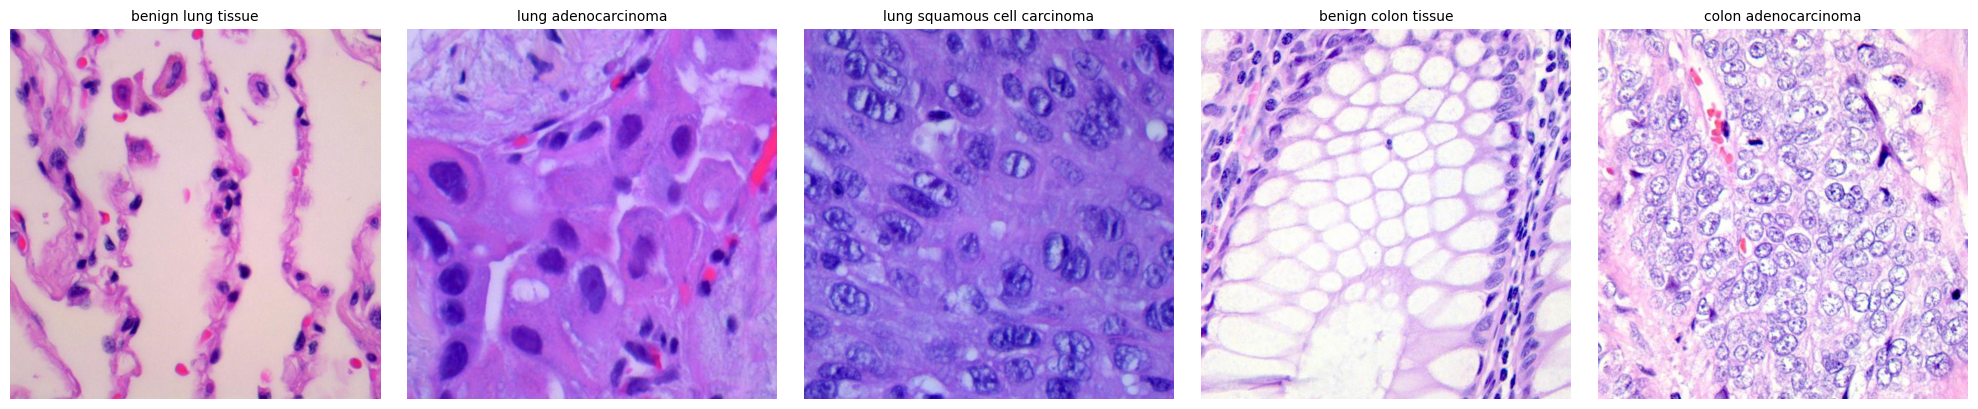

In [7]:
# --- Cell 6: visualize one sample per class ---
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for idx, info in enumerate(CLASS_INFO):
    sample_path = all_paths[all_indices == info.index][0]
    axes[idx].imshow(Image.open(sample_path).convert("RGB"))
    axes[idx].set_title(info.name, fontsize=10)
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

## 4 — Train / validation / test split

Loads the canonical split persisted by the baseline (seed 42, 80/10/10 stratified). If the file is missing it builds the same split deterministically.

In [8]:
# --- Cell 7: build or load the canonical split ---
if SPLIT_PATH.exists():
    split = load_split(SPLIT_PATH)
    print(f"Loaded existing split from {SPLIT_PATH}")
else:
    split = stratified_split(all_paths, all_indices, val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(split, SPLIT_PATH)
    print(f"Saved new split to {SPLIT_PATH}")

train_paths, train_indices = split["train_paths"], split["train_indices"]
val_paths, val_indices = split["val_paths"], split["val_indices"]
test_paths, test_indices = split["test_paths"], split["test_indices"]

print(f"Train: {len(train_paths)}  Val: {len(val_paths):4d}  Test: {len(test_paths):4d}")

split_counts = pd.DataFrame({
    "train": [int((train_indices == i).sum()) for i in range(NUM_CLASSES)],
    "val":   [int((val_indices   == i).sum()) for i in range(NUM_CLASSES)],
    "test":  [int((test_indices  == i).sum()) for i in range(NUM_CLASSES)],
}, index=[INDEX_TO_NAME[i] for i in range(NUM_CLASSES)])
split_counts

Saved new split to /content/histopathology-clip-lab/data/splits/lc25000_seed42.json
Train: 20000  Val: 2500  Test: 2500


,train,val,test
benign lung tissue,4000,500,500
lung adenocarcinoma,4000,500,500
lung squamous cell carcinoma,4000,500,500
benign colon tissue,4000,500,500
colon adenocarcinoma,4000,500,500


## 5 — Input pipeline

Per-sample we yield `(image, class_id)`. Image preprocessing scales pixels to [0, 1] via the shared `src.data.images.load_image` helper — matched to the keras_hub ResNet50 backbone's training convention.

In [9]:
# --- Cell 8: build train / val / test datasets ---
# Centralised loader: scales pixels to [0, 1] in RGB order — the convention the
# keras_hub `resnet_50_imagenet` backbone was trained with. Replaces the old
# `keras.applications.resnet.preprocess_input` (Caffe BGR + mean subtraction) call
# that produced degraded features against this backbone. See src/data/images.py.
from src.data.images import load_image


def make_dataset(paths, indices, *, shuffle):
    paths = tf.constant(np.asarray(paths))
    labels = tf.constant(np.asarray(indices), dtype=tf.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: (load_image(p), y), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_indices, shuffle=True)
val_ds   = make_dataset(val_paths,   val_indices,   shuffle=False)
test_ds  = make_dataset(test_paths,  test_indices,  shuffle=False)

# Quick smoke test.
imgs, lbls = next(iter(train_ds))
print("Train batch:")
print("  images:", imgs.shape, imgs.dtype)
print("  labels:", lbls.shape, lbls.dtype)


Train batch:
  images: (32, 224, 224, 3) <dtype: 'float32'>
  labels: (32,) <dtype: 'int32'>


## 6 — Model

The model is intentionally minimal: a frozen ResNet50 backbone, global-average-pooling to a single 2048-d vector per image, and a `Dense(5)` classifier on top. No text, no projection, no learnable temperature.

In [10]:
# --- Cell 9: backbone (ResNet50, fully frozen) ---
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
image_backbone.trainable = False

trainable_params = lambda m: sum(np.prod(v.shape) for v in m.trainable_variables)
print(f"Image backbone trainable params: {trainable_params(image_backbone):,}")

Image backbone trainable params: 0


In [11]:
# --- Cell 10: build the plain classifier ---
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")

# Frozen ResNet50 with running stats kept in inference mode (consistent with the baseline).
features = image_backbone(inputs, training=False)
# ResNet50 backbone always returns (B, H, W, C); GAP unconditionally.
features = keras.layers.GlobalAveragePooling2D(name="gap")(features)
# BatchNorm controls the feature scale per channel: it computes running
# mean/variance for each of the 2048 GAP'd features across the dataset,
# which preserves the cross-sample magnitude information that
# ResNet50's late filters encode. LayerNorm was tried first but
# collapsed each sample's 2048-d feature distribution to mean=0/var=1,
# destroying the per-channel scale that carries class signal — the
# linear probe converged at ~0.04 val accuracy per epoch.
features = keras.layers.BatchNormalization(name="feature_norm", dtype="float32")(features)

logits = keras.layers.Dense(
    NUM_CLASSES, name="classifier",
    kernel_initializer="glorot_uniform",
    dtype="float32",
)(features)

model = keras.Model(inputs=inputs, outputs=logits, name="plain_classifier")
model.summary(line_length=110)

Model: "plain_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                             │ (None, 224, 224, 3)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ res_net_backbone (ResNetBackbone)              │ (None, 7, 7, 2048)                  │          23,561,152 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ gap (GlobalAveragePooling2D)                   │ (None, 2048)                        │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ feature_norm (BatchNormalization)              │ (None, 2048)                        │               8,192 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ classifier (Dense)                             │ (None, 5)                           │              10,245 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 23,579,589 (89.95 MB)

 Trainable params: 14,341 (56.02 KB)

 Non-trainable params: 23,565,248 (89.89 MB)

In [12]:
# --- Cell 11: compile, smoke test ---
optimizer = keras.optimizers.AdamW(
    learning_rate=LR,
    weight_decay=WD,
    global_clipnorm=GLOBAL_CLIPNORM,
)
model.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)
_ = model(imgs[:1], training=False)
print(f"Total trainable params (Dense(5) head only): {trainable_params(model):,}")

Total trainable params (Dense(5) head only): 14,341


## 7 — Training

Same callback recipe as the baseline: `EarlyStopping(patience=5, restore_best_weights=True)`, `ReduceLROnPlateau(factor=0.5, patience=2)`, and `ModelCheckpoint` writing best weights to the run directory on each improvement.

In [13]:
# --- Cell 12: train ---
# Keras 3 requires the weights-only checkpoint filename to end with `.weights.h5`.
WEIGHTS_PATH = RUN_DIR / "weights.weights.h5"
HISTORY_PATH = RUN_DIR / "history.json"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(WEIGHTS_PATH),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1,
    ),
]

if not FORCE_RETRAIN and WEIGHTS_PATH.exists() and HISTORY_PATH.exists():
    print(f"Found cached weights at {WEIGHTS_PATH}; skipping training. (Set FORCE_RETRAIN=True in Cell 3 to override.)")
    model.load_weights(str(WEIGHTS_PATH))
    history_dict = json.loads(HISTORY_PATH.read_text())
    print(f"  loaded {len(history_dict.get('loss', []))} epoch(s) of history.")
else:
    if FORCE_RETRAIN and WEIGHTS_PATH.exists():
        print(f"FORCE_RETRAIN=True: ignoring existing weights at {WEIGHTS_PATH} and retraining.")
    elif WEIGHTS_PATH.exists():
        print(f"Weights exist but no history.json — retraining to regenerate the history file.")
    else:
        print("No cached weights at " + str(WEIGHTS_PATH) + ". Training from scratch.")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
    )
    HISTORY_PATH.write_text(json.dumps(history.history))
    history_dict = history.history
    print(f"Saved weights -> {WEIGHTS_PATH}")
    print(f"Saved history -> {HISTORY_PATH}")

No cached weights at /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5. Training from scratch.
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9147 - loss: 0.2327
Epoch 1: val_loss improved from None to 0.03814, saving model to /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 67ms/step - accuracy: 0.9619 - loss: 0.1070 - val_accuracy: 0.9880 - val_loss: 0.0381 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9887 - loss: 0.0354
Epoch 2: val_loss improved from 0.03814 to 0.02626, saving model to /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/

## 8 — Resume from a previous run *(skip if you just trained)*

If a weights file exists at `RUN_DIR / weights.weights.h5`, reload it. Otherwise this cell is a no-op.

In [14]:
# --- Cell 13: re-instantiate from disk (optional) ---
if WEIGHTS_PATH.exists():
    inputs_fresh = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    features_fresh = image_backbone(inputs_fresh, training=False)
    features_fresh = keras.layers.GlobalAveragePooling2D(name="gap")(features_fresh)
    features_fresh = keras.layers.BatchNormalization(name="feature_norm", dtype="float32")(features_fresh)
    logits_fresh = keras.layers.Dense(
        NUM_CLASSES, name="classifier",
        kernel_initializer="glorot_uniform", dtype="float32",
    )(features_fresh)
    model = keras.Model(inputs=inputs_fresh, outputs=logits_fresh, name="plain_classifier")
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=WD, global_clipnorm=GLOBAL_CLIPNORM),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    _ = model(imgs[:1], training=False)
    model.load_weights(str(WEIGHTS_PATH))
    print(f"Reloaded model from {WEIGHTS_PATH}")

    if HISTORY_PATH.exists():
        history_dict = json.loads(HISTORY_PATH.read_text())
    else:
        history_dict = None
else:
    history_dict = history.history if "history" in dir() else None

Reloaded model from /content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/weights.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 9 — Evaluation on the held-out test set

Predictions are the argmax of the softmax over the 5 classes. Identical eval to the baseline at the metric level, so the resulting numbers are directly comparable.

In [15]:
# --- Cell 14: classify the test set ---
true_class_ids = np.asarray(test_indices, dtype=np.int32)
logits_all = model.predict(test_ds, verbose=1)
predicted_class_ids = np.argmax(logits_all, axis=1).astype(np.int32)

print(f"Logits shape:    {logits_all.shape}")
print(f"True / pred:     {true_class_ids.shape} {predicted_class_ids.shape}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step
Logits shape:    (2500, 5)
True / pred:     (2500,) (2500,)


In [16]:
# --- Cell 15: classification metrics ---
acc      = accuracy_score(true_class_ids, predicted_class_ids)
bal_acc  = balanced_accuracy_score(true_class_ids, predicted_class_ids)
macro_f1 = f1_score(true_class_ids, predicted_class_ids, average="macro")
weighted_f1 = f1_score(true_class_ids, predicted_class_ids, average="weighted")

print("Global metrics:")
print(f"  {'accuracy':>20}: {acc:.4f}")
print(f"  {'balanced_accuracy':>20}: {bal_acc:.4f}")
print(f"  {'macro_f1':>20}: {macro_f1:.4f}")
print(f"  {'weighted_f1':>20}: {weighted_f1:.4f}")

display_labels = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]
report = classification_report(
    true_class_ids, predicted_class_ids,
    target_names=display_labels, output_dict=True, zero_division=0,
)
report_df = pd.DataFrame(report).T
report_df

Global metrics:
              accuracy: 0.9952
     balanced_accuracy: 0.9952
              macro_f1: 0.9952
           weighted_f1: 0.9952


,precision,recall,f1-score,support
benign lung tissue,1.000000,0.9980,0.998999,500.0000
lung adenocarcinoma,0.988024,0.9900,0.989011,500.0000
lung squamous cell carcinoma,0.990000,0.9900,0.990000,500.0000
benign colon tissue,1.000000,0.9980,0.998999,500.0000
colon adenocarcinoma,0.998004,1.0000,0.999001,500.0000
accuracy,0.995200,0.9952,0.995200,0.9952
macro avg,0.995206,0.9952,0.995202,2500.0000
weighted avg,0.995206,0.9952,0.995202,2500.0000


In [17]:
# --- Cell 16: save metrics ---
metrics_path = METRICS_DIR / f"{VERSION}_classification.json"
metrics_path.write_text(json.dumps({
    "version": VERSION,
    "accuracy": float(acc),
    "balanced_accuracy": float(bal_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
}, indent=2))
print(f"Saved -> {metrics_path}")

per_class_csv_path = METRICS_DIR / f"{VERSION}_per_class.csv"
per_class_df = pd.DataFrame({
    "class": display_labels,
    "precision": [report[name]["precision"] for name in display_labels],
    "recall":    [report[name]["recall"]    for name in display_labels],
    "f1":        [report[name]["f1-score"]  for name in display_labels],
    "support":   [report[name]["support"]   for name in display_labels],
})
per_class_df.to_csv(per_class_csv_path, index=False)
print(f"Saved -> {per_class_csv_path}")

Saved -> /content/histopathology-clip-lab/results/metrics/plain_classifier_classification.json
Saved -> /content/histopathology-clip-lab/results/metrics/plain_classifier_per_class.csv


## 10 — Confusion matrices

Raw counts + row-normalised — the same two-panel figure the baseline and other ablations produce, so the chapter's CM comparisons stay visually consistent.

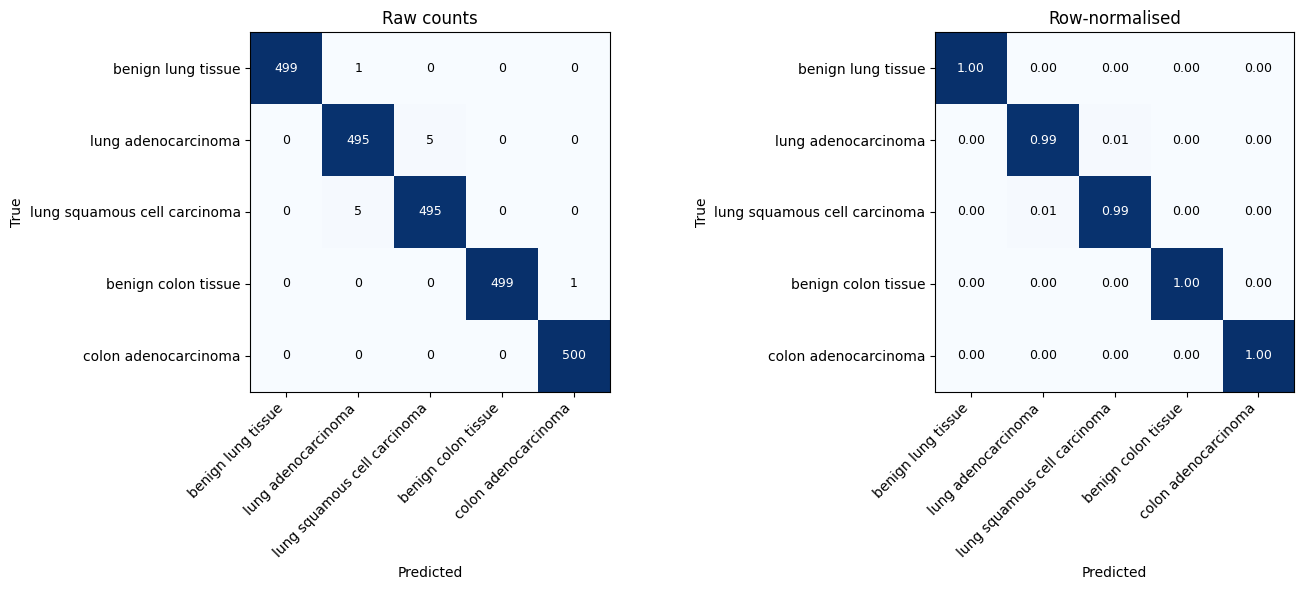

Saved -> /content/histopathology-clip-lab/results/confusion_matrices/plain_classifier_confusion_matrices.png


In [18]:
# --- Cell 17: confusion matrices ---
cm_raw = confusion_matrix(true_class_ids, predicted_class_ids, labels=list(range(NUM_CLASSES)))
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, title in [(ax1, cm_raw, "Raw counts"), (ax2, cm_norm, "Row-normalised")]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(display_labels, rotation=45, ha="right")
    ax.set_yticklabels(display_labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{title}")
    fmt = "d" if mat.dtype.kind in "iu" else ".2f"
    threshold = mat.max() * 0.5
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > threshold else "black", fontsize=9)
plt.tight_layout()

cm_plot_path = CM_DIR / f"{VERSION}_confusion_matrices.png"
fig.savefig(cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {cm_plot_path}")

# Persist raw arrays too for downstream analysis.
np.save(CM_DIR / f"{VERSION}_cm_raw.npy", cm_raw)
np.save(CM_DIR / f"{VERSION}_cm_norm.npy", cm_norm)

## 11 — Training curves

Loss and accuracy across epochs. With the head being a single Dense(5) on top of frozen features, expect convergence within the first ~10 epochs followed by EarlyStopping.

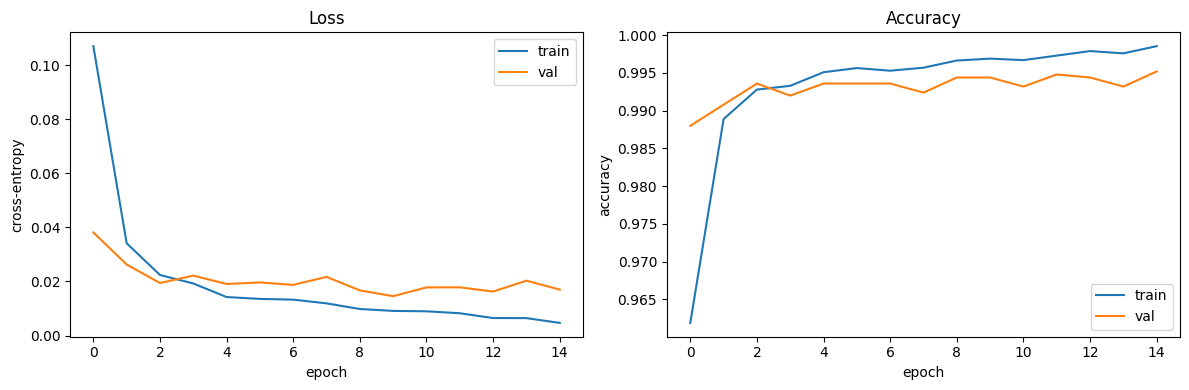

Saved -> /content/histopathology-clip-lab/results/plots/plain_classifier_loss.png


In [19]:
# --- Cell 18: plot training history ---
if history_dict is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict.get("loss", []), label="train")
    axes[0].plot(history_dict.get("val_loss", []), label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(history_dict.get("accuracy", []), label="train")
    axes[1].plot(history_dict.get("val_accuracy", []), label="val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    loss_path = PLOTS_DIR / f"{VERSION}_loss.png"
    fig.savefig(loss_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {loss_path}")
else:
    print("No history available — re-run from training cell or load history.json.")

## 12 — UMAP of the frozen image features

Because there is no text encoder, the shared-UMAP recipe used by the baseline / PLIP / unfreeze30 does not apply here. Instead we run UMAP on the GAP'd 2048-d ResNet50 features (what the classifier head sees) and colour by true class. This is directly comparable to the baseline UMAP if you mentally remove the prompt markers.

In [20]:
# --- Cell 19: extract features from frozen ResNet50 ---
feature_model = keras.Model(inputs=model.inputs, outputs=model.get_layer("gap").output)

test_features_list = []
for images, _ in test_ds:
    feats = feature_model(images, training=False).numpy()
    test_features_list.append(feats)
test_features = np.concatenate(test_features_list, axis=0)
print(f"Test feature shape: {test_features.shape}")

Test feature shape: (2500, 2048)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


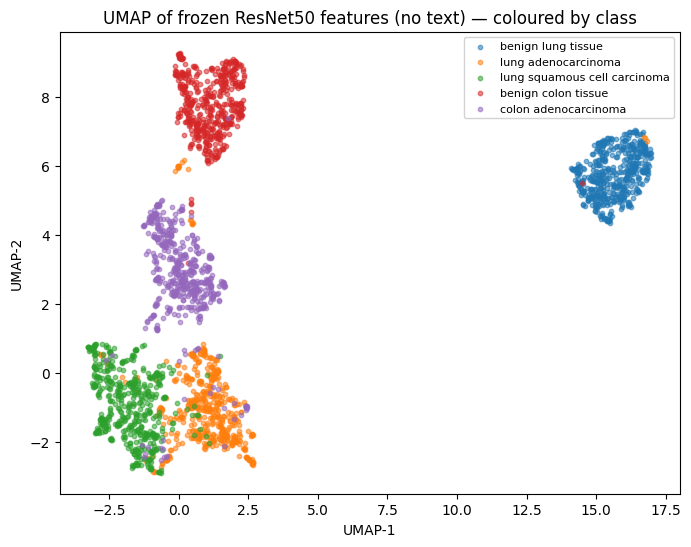

Saved -> /content/histopathology-clip-lab/results/plots/plain_classifier_umap.png


In [21]:
# --- Cell 20: UMAP plot, coloured by true class ---
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
features_2d = reducer.fit_transform(test_features)

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(NUM_CLASSES):
    mask = true_class_ids == i
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
               s=10, alpha=0.55, label=INDEX_TO_NAME[i])
ax.set_title("UMAP of frozen ResNet50 features (no text) — coloured by class")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(loc="best", fontsize=8, framealpha=0.85)

umap_path = PLOTS_DIR / f"{VERSION}_umap.png"
fig.savefig(umap_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_path}")

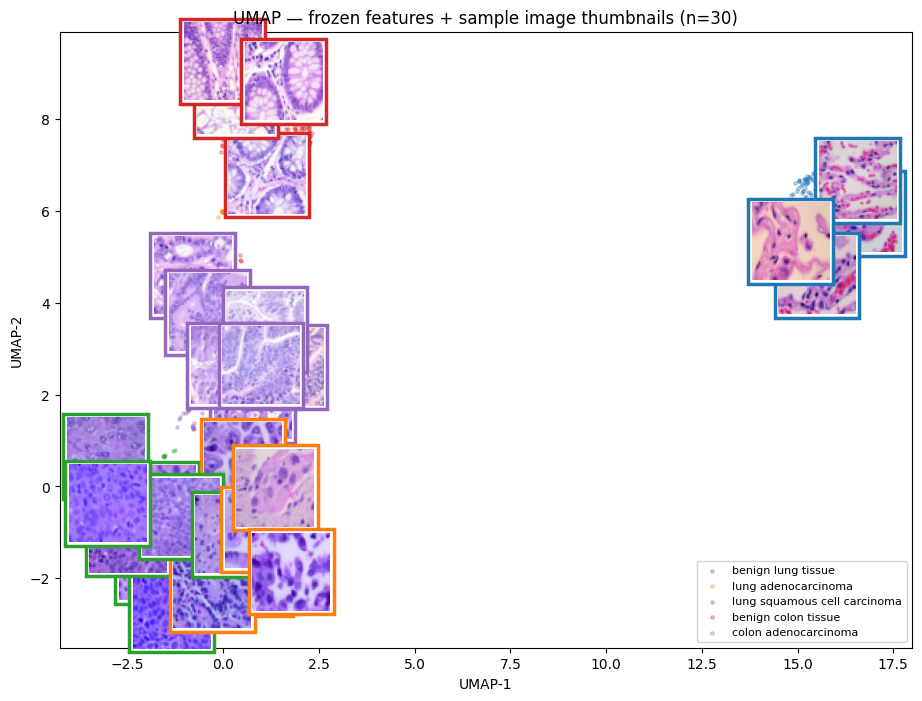

Saved -> /content/histopathology-clip-lab/results/plots/plain_classifier_umap_thumbnails.png


In [22]:
# --- Cell 21: thumbnail UMAP overlay (image-side only; no text in this ablation) ---
# Reuses the shared helper with text_2d=None to skip prompt markers.
class_names = [INDEX_TO_NAME[i] for i in range(NUM_CLASSES)]
fig = plot_umap_thumbnails(
    image_2d=features_2d,
    image_paths=list(test_paths),
    image_labels=true_class_ids,
    text_2d=None,
    class_names=class_names,
    title="UMAP — frozen features + sample image thumbnails",
)
umap_thumbs_path = PLOTS_DIR / f"{VERSION}_umap_thumbnails.png"
fig.savefig(umap_thumbs_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_thumbs_path}")

## 13 — Summary

Artifact bundle, prefixed by `VERSION = "plain_classifier"`:

- `results/metrics/plain_classifier_classification.json`
- `results/metrics/plain_classifier_per_class.csv`
- `results/confusion_matrices/plain_classifier_cm_{raw,norm}.npy`
- `results/confusion_matrices/plain_classifier_confusion_matrices.png`
- `results/plots/plain_classifier_loss.png`
- `results/plots/plain_classifier_umap.png`
- `results/plots/plain_classifier_umap_thumbnails.png`

The headline number to report in the thesis is the macro-F1 delta vs the CLIP baseline (`results/metrics/baseline_classification.json`). If the plain classifier ties or wins, the CLIP paradigm's contribution to *raw classification accuracy* on this 5-class problem is zero, and the paradigm's value lives in capabilities (open-vocabulary, retrieval) rather than accuracy. If the CLIP baseline wins, image–text alignment is contributing beyond what the frozen features alone can support.

Weights and history live at `RUN_DIR` on Drive (`/content/drive/MyDrive/clip_histopathology/exp_03_plain_classifier/plain_classifier/`).